<a href="https://colab.research.google.com/github/Jette-j/Computervision/blob/main/exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1.
2.
3.
4.
5.


In [18]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [20]:
def load_image_gray(image_path):
    image = cv2.imread(image_path) # Liest Bild als BGR (Farbe)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Umwandlung zu Graustufen
    return image  # Werte: 0-255 (Integer)

In [21]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.
# Normalisieren Werte: 0.0-1.0 (Float) → wichtig für spätere Berechnungen!

In [36]:
def gradient(image):
    v = .5
    # Kernel für dy: schaut oben und unten
    k_y = np.zeros((3, 3))
    print (k_y)
    k_y[0, 1] = -v # oberer Nachbar  → negativ
    k_y[2, 1] = +v # unterer Nachbar → positiv

    # Kernel für dx: schaut links und rechts
    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v # linker Nachbar  → negativ
    k_x[1, 2] = +v # rechter Nachbar → positiv

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x) # CONVOLUTION mit k_x
    gradient_y = cv2.filter2D(image, -1, k_y) # CONVOLUTION mit k_Y
    #cv2.filter2D schiebt den Kernel über jeden Pixel und berechnet die gewichtete Summe der Nachbarn — das ist eine Faltung (Convolution).
    return gradient_x, gradient_y


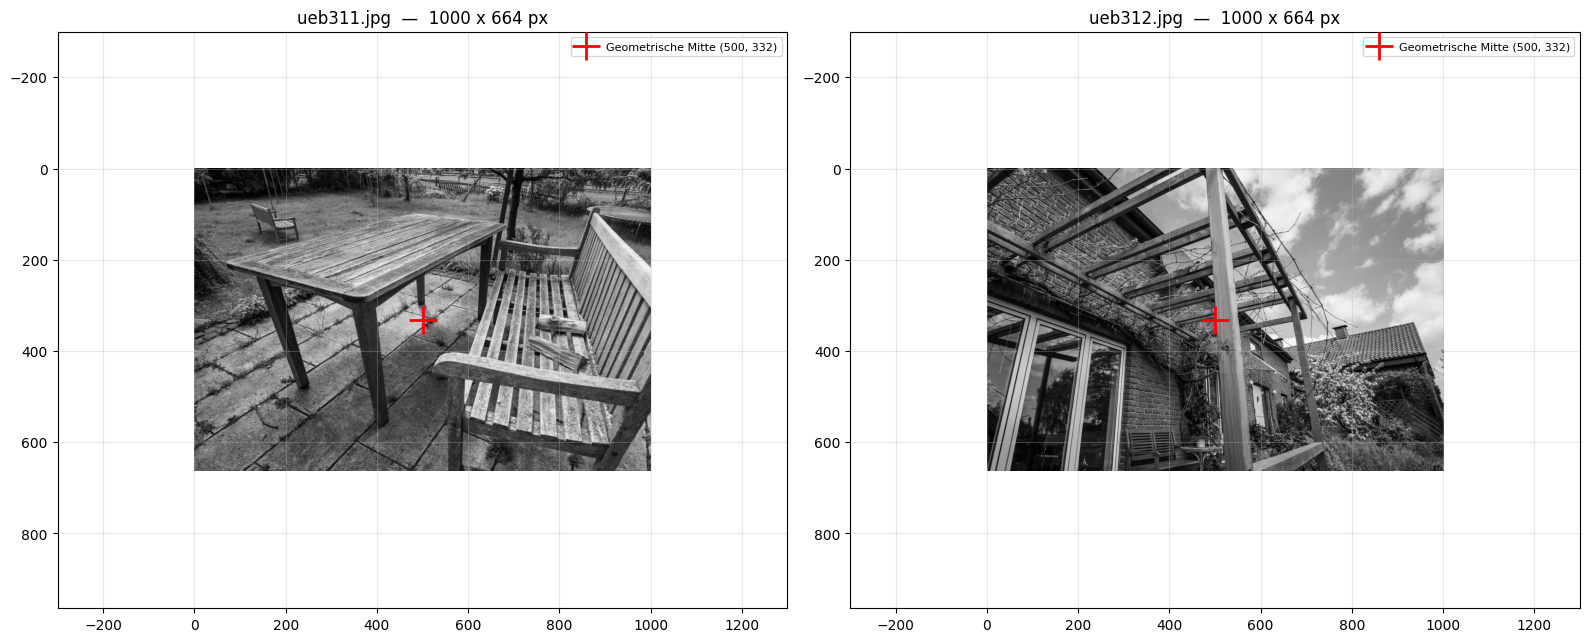

In [47]:
# load images
img311 = load_image_gray_normalized('/content/cs4250/data/exercise_3/ueb311.jpg')
img312 = load_image_gray_normalized('/content/cs4250/data/exercise_3/ueb312.jpg')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

estimated_center_311 = (0, 0)   # <- ersetzen
estimated_center_312 = (0, 0)   # <- ersetzen

for ax, img, name, est_center in zip(axes, [img311, img312], ['ueb311.jpg', 'ueb312.jpg'],  [estimated_center_311, estimated_center_312]):
    h, w = img.shape

    # Bild mit extra Rand anzeigen (damit Linien über den Rand hinaus gehen)
    ax.imshow(img, cmap='gray', extent=[0, w, h, 0])
    ax.set_xlim(-300, w+300)   # extra Platz links/rechts
    ax.set_ylim(h+300, -300)   # extra Platz oben/unten
    #geomatrical center
    ax.plot(w/2, h/2, 'r+', markersize=20, markeredgewidth=2, label=f'Geometrische Mitte ({w/2:.0f}, {h/2:.0f})')

    #image center
    ax.plot( est_center[0], est_center[1], 'bx', markersize=12, markeredgewidth=2,
        label=f'Geschätzte Mitte (Ruler) {est_center}'
    )

    ax.set_title(f'{name}  —  {w} x {h} px')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


#plt.suptitle('Image Center (mit Rand zum Messen)', fontsize=13)
plt.tight_layout()
plt.show()

## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


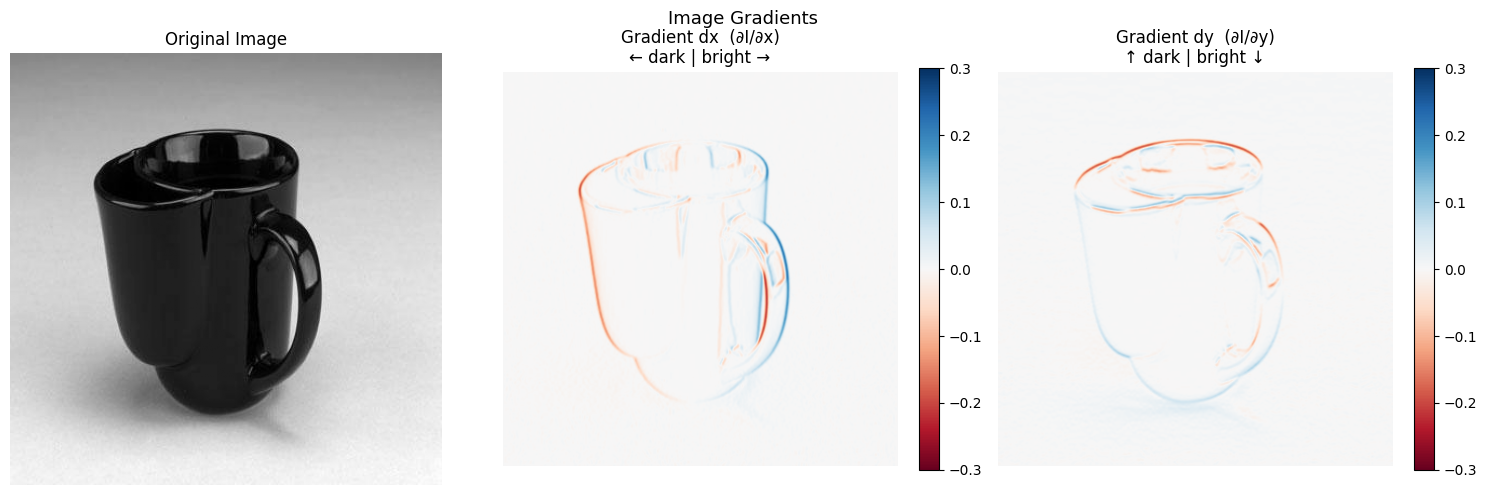

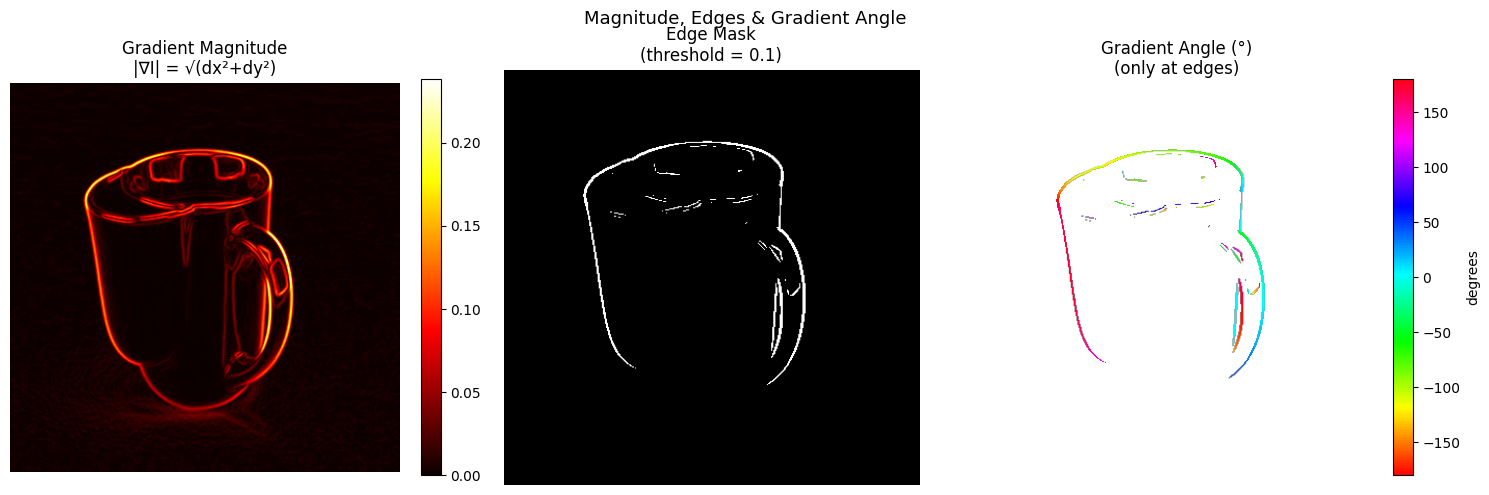

In [39]:
# load image
img32 = load_image_gray_normalized('/content/cs4250/data/exercise_3/ueb32.jpg')

# smooth image (Gaussian blur to reduce noise before gradient)
img_smooth = cv2.GaussianBlur(img32, (5, 5), sigmaX=1.0)

# compute and show gradient images
gx, gy = gradient(img_smooth)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img32, cmap='gray')
axes[0].set_title('Original Image')

# make images comparable (use same scale for comparability)
# vmin/vmax symmetric around 0 → makes dx and dy directly comparable
vlim = 0.3
axes[1].imshow(gx, cmap='RdBu', vmin=-vlim, vmax=vlim)
axes[1].set_title('Gradient dx  (∂I/∂x)\n← dark | bright →')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

axes[2].imshow(gy, cmap='RdBu', vmin=-vlim, vmax=vlim)
axes[2].set_title('Gradient dy  (∂I/∂y)\n↑ dark | bright ↓')
plt.colorbar(axes[2].images[0], ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis('off')
plt.suptitle('Image Gradients', fontsize=13)
plt.tight_layout()
plt.show()

# compute gradient magnitude
magnitude = np.sqrt(gx**2 + gy**2)

# compute an angle image that should be in range [-180,+180]
# --- Threshold to keep only real edges ---
threshold = 0.1
edge_mask = magnitude > threshold

# --- Gradient angle in degrees [-180, +180] ---
angle_deg = np.degrees(np.arctan2(gy, gx))   # arctan2(dy, dx) !


# show angles only for real edges
angle_masked = np.where(edge_mask, angle_deg, np.nan)

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(magnitude, cmap='hot')
axes[0].set_title(f'Gradient Magnitude\n|∇I| = √(dx²+dy²)')
plt.colorbar(axes[0].images[0], ax=axes[0], fraction=0.046)

axes[1].imshow(edge_mask, cmap='gray')
axes[1].set_title(f'Edge Mask\n(threshold = {threshold})')

im = axes[2].imshow(angle_masked, cmap='hsv', vmin=-180, vmax=180)
axes[2].set_title('Gradient Angle (°)\n(only at edges)')
plt.colorbar(im, ax=axes[2], fraction=0.046, label='degrees')

for ax in axes:
    ax.axis('off')
plt.suptitle('Magnitude, Edges & Gradient Angle', fontsize=13)
plt.tight_layout()
plt.show()

"How can you tell the angle from dx and dy?"

Den Winkel kann man direkt aus den Vorzeichen und Verhältnissen von dx und dy ablesen:
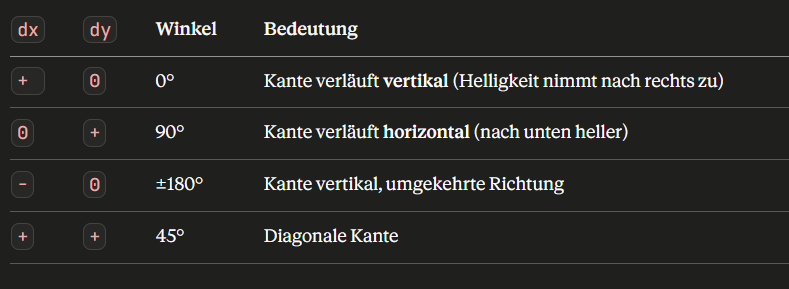

Konkret: θ = arctan2(dy, dx) — der Gradient zeigt immer senkrecht zur Kante, in Richtung zunehmender Helligkeit. Eine Kante die man im dx-Bild stark sieht aber nicht im dy-Bild, ist eine vertikale Kante (Winkel ≈ 0° oder ±180°), und umgekehrt.Du hast gesagt: Exercise 3.

## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.**Furthermore, comment how the angle image and the magnitude image are used in the Canny algorithm.**

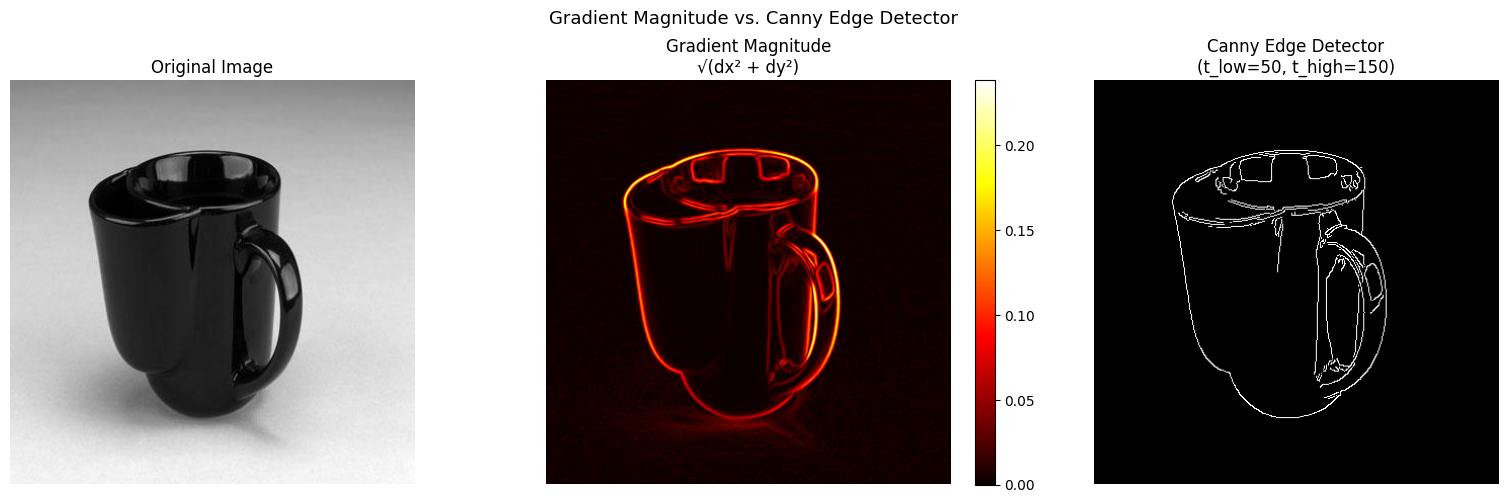

In [24]:
# compute magnitude of gradient image (same as 3.2.1)
gx, gy = gradient(img_smooth)
magnitude = np.sqrt(gx**2 + gy**2)
# apply canny - cv2.Canny expects uint8 input
img_uint8 = (img32 * 255).astype(np.uint8)
canny_edges = cv2.Canny(img_uint8, threshold1=50, threshold2=150)
# compare results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img32, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(magnitude, cmap='hot')
axes[1].set_title('Gradient Magnitude\n√(dx² + dy²)')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

axes[2].imshow(canny_edges, cmap='gray')
axes[2].set_title(f'Canny Edge Detector\n(t_low=50, t_high=150)')
axes[2].axis('off')

plt.suptitle('Gradient Magnitude vs. Canny Edge Detector', fontsize=13)
plt.tight_layout()
plt.show()

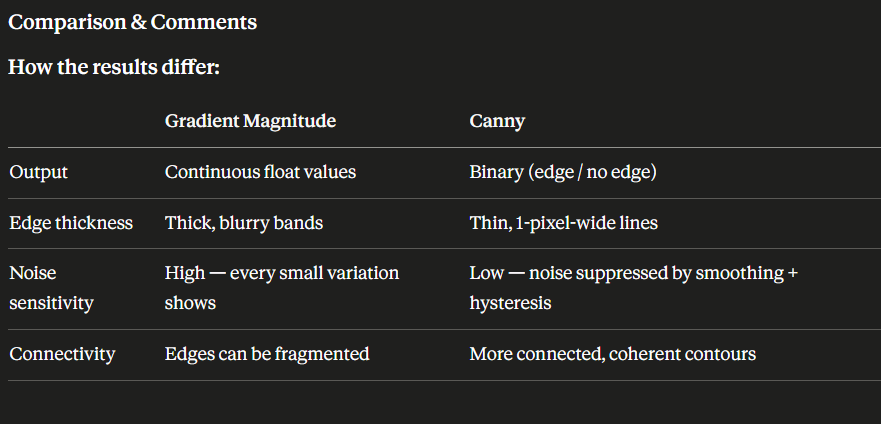

Canny is essentially a refined pipeline built on top of exactly the two images from 3.2.1:

Gradient magnitude → tells where intensity changes are strong. Used in both NMS and the two thresholds.
Gradient angle → used in Non-Maximum Suppression (NMS): for each pixel, the algorithm looks at the two neighbours along the gradient direction (i.e. perpendicular to the edge). Only the local maximum in that direction is kept → this is what thins the thick magnitude bands down to 1-pixel-wide edges.
After NMS, hysteresis thresholding with t_low and t_high uses the magnitude values to classify pixels:

magnitude > t_high  → definite edge (strong)
t_low < mag ≤ t_high → edge only if connected to a strong edge (weak)
magnitude ≤ t_low   → suppressed (not an edge)
So in short: the angle image sharpens the edges, and the magnitude image selects and connects them.

## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [25]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [26]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [27]:
def key_points_structure(image, alpha, sigma=.1):

    # image parameters
    h, w = image.shape

    # 0. filter with Gaussian kernel with sigma
    smoothed = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma)

    # 1. partial derivatives
    dx, dy = gradient(smoothed)

    # 2. product images (components of structure tensor J)
    dx2 = dx ** 2        # J_xx
    dy2 = dy ** 2        # J_yy
    dxdy = dx * dy       # J_xy

    # 3. filter with gaussian kernel with sigma = 1
    #    This is the KEY step: it accumulates gradient information over a local region,
    #    turning point-wise derivatives into a proper local structure descriptor.
    sigma2 = 1.0
    J_xx = cv2.GaussianBlur(dx2,  (0, 0), sigmaX=sigma2)
    J_yy = cv2.GaussianBlur(dy2,  (0, 0), sigmaX=sigma2)
    J_xy = cv2.GaussianBlur(dxdy, (0, 0), sigmaX=sigma2)

    # 4. compute invarians for J
    #    Trace:       H = J_xx + J_yy         (= λ1 + λ2)
    #    Determinant: K = J_xx*J_yy - J_xy²   (= λ1 * λ2)
    H = J_xx + J_yy
    K = J_xx * J_yy - J_xy ** 2

    K_minus_H = K - alpha * H**2

    return K, K_minus_H


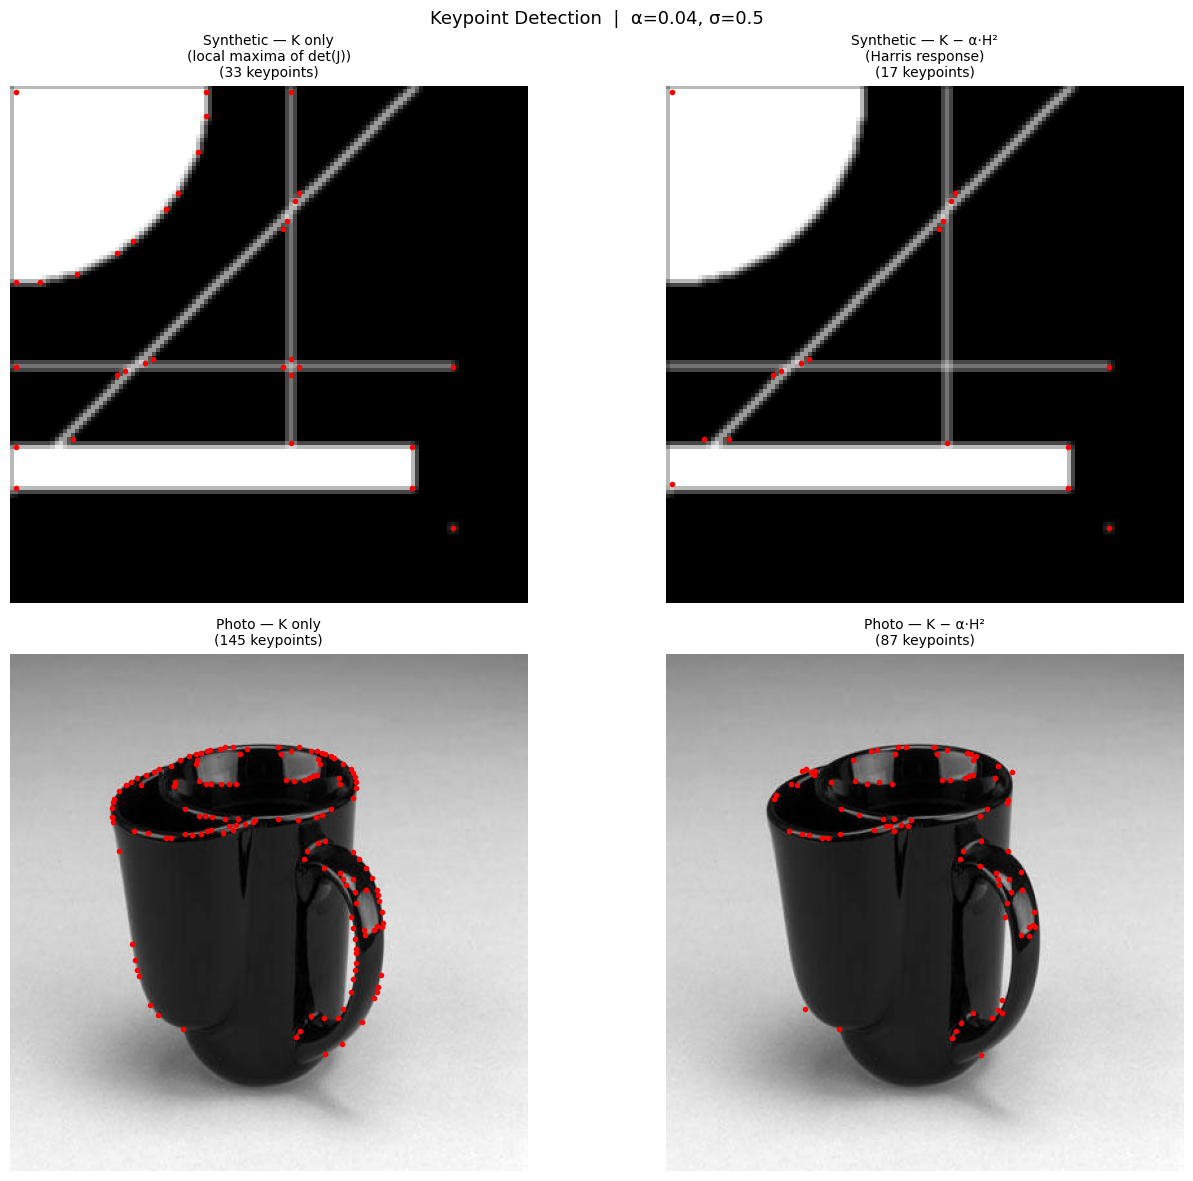

'\n_, ax = plt.subplots(2, 2, figsize=(15, 15))\nlocal_max = find_local_max(keypoints_K)\nax[0][0].imshow(image)\nplot_marks(local_max, ax[0][0])\n\nlocal_max = find_local_max(keypoints_K_minus_H)\nax[0][1].imshow(image)\nplot_marks(local_max, ax[0][1])\n'

In [28]:
# define alpha, sigma, and k
alpha = 0.04    # Harris weighting factor (typical range: 0.04–0.06)
sigma = 0.5     # pre-smoothing sigma
k     = 3       # NMS neighbourhood size

# load images
img_synth = np.load('/content/cs4250/data/exercise_3/ueb331.npy').astype('float32')
if img_synth.max() > 1.0:
    img_synth /= 255.0

img_photo = load_image_gray_normalized('/content/cs4250/data/exercise_3/ueb332.jpg')

# extract keypoints
K_synth,   KH_synth   = key_points_structure(img_synth, alpha=alpha, sigma=sigma)
K_photo,   KH_photo   = key_points_structure(img_photo, alpha=alpha, sigma=sigma)

# show found keypoints (K, K_minus_H) for both images
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

titles = [
    'Synthetic — K only\n(local maxima of det(J))',
    'Synthetic — K − α·H²\n(Harris response)',
    'Photo — K only',
    'Photo — K − α·H²',
]
images    = [img_synth, img_synth, img_photo, img_photo]
keypoints = [K_synth,   KH_synth,  K_photo,   KH_photo ]

for i, (a, title, im, kp) in enumerate(zip(ax.flat, titles, images, keypoints)):
    lm = find_local_max(kp,  thres=1e-7, k=3)   # niedrigerer Threshold
    a.imshow(im, cmap='gray')
    plot_marks(lm, a)
    a.set_title(f'{title}\n({lm.sum()} keypoints)', fontsize=10)
    a.axis('off')

plt.suptitle(f'Keypoint Detection  |  α={alpha}, σ={sigma}', fontsize=13)
plt.tight_layout()
plt.show()
# example
"""
_, ax = plt.subplots(2, 2, figsize=(15, 15))
local_max = find_local_max(keypoints_K)
ax[0][0].imshow(image)
plot_marks(local_max, ax[0][0])

local_max = find_local_max(keypoints_K_minus_H)
ax[0][1].imshow(image)
plot_marks(local_max, ax[0][1])
"""

1. Localization of keypoints

K only (det J): detects corners well but also fires on edges and flat regions because det(J) > 0 whenever both eigenvalues are large — but small numerical det values on edges can still pass the threshold.
K − αH²: subtracts a penalty proportional to the squared trace, suppressing responses wherever one eigenvalue dominates (edges) or both are small (flat). Only true corners — where both eigenvalues are large — survive.

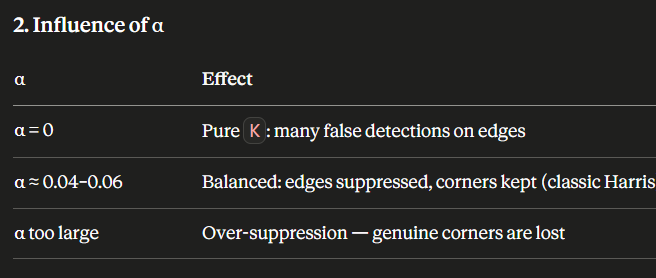

Answer: Why the second Gaussian filter (step 3)?
The second Gaussian (on the product images dx², dy², dx·dy) is not about noise — it implements the local integration that defines the structure tensor:

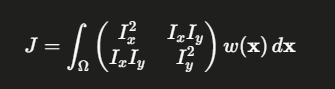

Without it, J would be a rank-1 matrix at every single pixel (outer product of one gradient vector), which always has det(J) = 0 — making corner detection impossible. The Gaussian averaging pools gradient information over a neighbourhood, allowing the tensor to capture the distribution of gradient directions in a local region, which is what distinguishes corners (two dominant directions) from edges (one) and flat areas (none).